In [1]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================
!pip install -q transformers peft accelerate bitsandbytes datasets trl scikit-learn matplotlib seaborn evaluate bert_score


In [ ]:
# Runtime -> restart session for bitsandbytes

In [2]:
# ============================================================
# CELL 2 — MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import os
import shutil
import json
import torch
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer

DRIVE_ROOT = '/content/drive/MyDrive/298B_WB2'
# Copy the JSONL from drive
shutil.copy(f'{DRIVE_ROOT}/planner_train_graphrag.jsonl', '/content/planner_train_graphrag.jsonl')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/planner_train_graphrag.jsonl'

In [3]:
# ============================================================
# CELL 3 — CONFIGURATION & DATA PREP (80-10-10 Split)
# ============================================================
BASE_MODEL = 'Qwen/Qwen2.5-Coder-7B-Instruct'
OUTPUT_DIR = f'{DRIVE_ROOT}/training_run_planner_v2'
ADAPTER_DIR = f'{DRIVE_ROOT}/planner_lora_adapter_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ADAPTER_DIR, exist_ok=True)

records = []
with open('/content/planner_train_graphrag.jsonl', 'r') as f:
    for line in f:
        if line.strip():
            data = json.loads(line)
            ft = f"<|im_start|>user\n{data['input']}<|im_end|>\n<|im_start|>assistant\n{data['output']}<|im_end|>"
            records.append({'text': ft, 'label': 'YES' if 'REQUIRES_CODE_CHANGE: YES' in data['output'] else 'NO', 'original_output': data['output']})

df = pd.DataFrame(records)
print(f'Loaded {len(df)} GraphRAG samples.')

# 80-10-10 Split
# 1. Split off 10% for completely blind testing at the very end
train_val_df, test_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)

# 2. Split the remaining 90% into Train (80%) and Validation (10%)
# (0.1111 of 90% is roughly 10% of the total 100%)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, stratify=train_val_df['label'], random_state=42)

train_ds = Dataset.from_pandas(train_df[['text']])
val_ds = Dataset.from_pandas(val_df[['text']])
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Blind): {len(test_df)}')


Loaded 3000 GraphRAG samples.
Train: 2400 | Val: 300 | Test (Blind): 300


In [4]:
# ============================================================
# CELL 4 — VERIFY TOKENIZER & LOAD MODEL
# ============================================================
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

TOKENIZER = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
TOKENIZER.pad_token = TOKENIZER.eos_token
TOKENIZER.padding_side = 'right'

print(f'Loading {BASE_MODEL}...')
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=torch.bfloat16,
    device_map='auto', trust_remote_code=True
)
model.config.use_cache = False

model = get_peft_model(model, LoraConfig(
    r=32, lora_alpha=64,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj', 'gate_proj', 'up_proj'],
    lora_dropout=0.05,
    bias='none', task_type=TaskType.CAUSAL_LM
))
model.print_trainable_parameters()


Loading Qwen/Qwen2.5-Coder-7B-Instruct...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

trainable params: 60,555,264 || all params: 7,676,171,776 || trainable%: 0.7889


In [5]:
# ============================================================
# CELL 5 — TRAIN (WITH BEST MODEL LOADING)
# ============================================================
from trl import SFTConfig
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    logging_steps=10,
    max_length=2048,
    num_train_epochs=3,
    eval_strategy='steps',
    eval_steps=50,
    save_strategy='steps',
    save_steps=50,
    save_total_limit=2, # Only keeping last 2 checkpoints to save disk space
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False, # Lower eval_loss = better
    bf16=True,
    dataset_text_field='text',
    report_to='none'
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,  # Using the 10% validation set during active training
    args=training_args
)

trainer.train()
trainer.model.save_pretrained(ADAPTER_DIR)
TOKENIZER.save_pretrained(ADAPTER_DIR)
print('Adapter saved (Guaranteed Best Loss Model!)')


Adding EOS to train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
50,1.084645,1.084898
100,0.972083,1.021964
150,0.968376,0.985488
200,0.866391,0.964259
250,0.887833,0.944677
300,0.824795,0.933066
350,0.766330,0.934346
400,0.775344,0.929935
450,0.752964,0.926946


Adapter saved (Guaranteed Best Loss Model!)


In [5]:
# Run this post-restart to load your persisted adapter on drive for CELL 6 evals
from peft import PeftModel
# This replaces the 'fresh' LoRA layers with your trained ones
model = PeftModel.from_pretrained(model, ADAPTER_DIR)
print("Successfully loaded trained Planner adapters!")


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Successfully loaded trained Planner adapters!


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0

Running inference on Blind Test Set...


  0%|          | 0/50 [00:00<?, ?it/s]

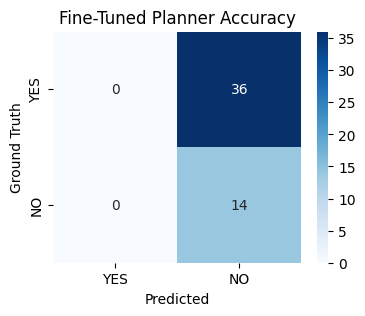

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[FINAL METRICS]
Recall: 0.0000
BERTScore: 0.8231


In [11]:
# ============================================================
# CELL 6 — EVAL: COMPREHENSIVE METRICS
# ============================================================
import torch
import re
import os
import json
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

# --- 1. HELPERS ---
def extract_files(text):
    # 1. Strip out markdown bolding to normalize the text
    clean_text = text.replace('**', '')

    # 2. Case-insensitive search for the target files block
    match = re.search(r'(?i)Target files:\s*(.*?)(?:\n\s*[-\*•]*\s*Test strategy:|$)', clean_text, re.DOTALL)
    if not match: return set()

    files_block = match.group(1).strip()
    if files_block.lower() in ['none', 'none.', 'n/a']: return set()

    # 3. Extract filenames from bulleted list
    files = re.findall(r'(?m)^\s*[-\*•]\s+([^\n\r]+)', files_block)
    return set(f.strip() for f in files if f.strip() not in ['None', 'None.'])

def extract_classification(text):
    match = re.search(r'REQUIRES_CODE_CHANGE:\s*(YES|NO)', text, re.IGNORECASE)
    return match.group(1).upper() if match else 'UNKNOWN'

# --- 2. THE GENERATION ENGINE (Fixed for PEFT State) ---
def generate_prediction(test_input, use_adapter=True):
    prompt = f"<|im_start|>user\n{test_input}<|im_end|>\n<|im_start|>assistant\n"
    inputs = TOKENIZER(prompt, return_tensors='pt').to(model.device)

    with torch.no_grad():
        if use_adapter:
            # Standard generation with LoRA active
            outputs = model.generate(**inputs, max_new_tokens=300, do_sample=False)
        else:
            # Baseline generation using context manager to "hide" LoRA
            with model.disable_adapter():
                outputs = model.generate(**inputs, max_new_tokens=300, do_sample=False)

    return TOKENIZER.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

# --- 3. THE EVALUATION LOOP ---
eval_samples = test_df.sample(min(50, len(test_df)), random_state=42)
gt_classes, ft_classes = [], []
gt_texts, ft_texts = [], []
ft_file_recalls = []

print("Running inference on Blind Test Set...")
for row in tqdm(eval_samples.itertuples(), total=len(eval_samples)):
    # Reconstruct input from ChatML string
    input_part = row.text.split('<|im_start|>user\n')[1].split('<|im_end|>')[0]

    # Run Inference
    f_out = generate_prediction(input_part, use_adapter=True)

    # Store Data
    gt_classes.append('YES' if 'REQUIRES_CODE_CHANGE: YES' in row.original_output else 'NO')
    ft_classes.append(extract_classification(f_out))
    gt_texts.append(row.original_output)
    ft_texts.append(f_out)

    # Calculate File Recall
    gt_files = extract_files(row.original_output)
    ft_files = extract_files(f_out)
    if len(gt_files) > 0:
        intersection = len(gt_files.intersection(ft_files))
        ft_file_recalls.append(intersection / len(gt_files))

# --- 4. PERSISTENT REPORTING ---
eval_report_dict = {}

# Classification
def plot_cm(y_true, y_pred, title, filename_prefix):
    y_p_clean = ['NO' if y == 'UNKNOWN' else y for y in y_pred]
    cm = confusion_matrix(y_true, y_p_clean, labels=['YES', 'NO'])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['YES', 'NO'], yticklabels=['YES', 'NO'])
    plt.ylabel('Ground Truth'); plt.xlabel('Predicted'); plt.title(title)
    plt.savefig(os.path.join(ADAPTER_DIR, f'{filename_prefix}_cm.png'), bbox_inches='tight')
    plt.show()
    return classification_report(y_true, y_p_clean, labels=['YES', 'NO'], output_dict=True)

eval_report_dict['classification'] = plot_cm(gt_classes, ft_classes, 'Fine-Tuned Planner Accuracy', 'finetuned')

# Metrics
eval_report_dict['file_recall'] = sum(ft_file_recalls) / len(ft_file_recalls) if ft_file_recalls else 0
bertscore = evaluate.load("bertscore")
ft_bert = bertscore.compute(predictions=ft_texts, references=gt_texts, lang="en")
eval_report_dict['bertscore_f1'] = sum(ft_bert['f1']) / len(ft_bert['f1'])

print(f"\n[FINAL METRICS]\nRecall: {eval_report_dict['file_recall']:.4f}\nBERTScore: {eval_report_dict['bertscore_f1']:.4f}")

with open(os.path.join(ADAPTER_DIR, 'eval_metrics_final.json'), 'w') as f:
    json.dump(eval_report_dict, f, indent=4)

In [ ]:
# ============================================================
# CELL 7A — PUSH ADAPTER TO HUGGINGFACE HUB
# Since we are using Multi-LoRA on HF Inference endpoints,
# the adapter needs to be hosted on the Hub.
# ============================================================
from huggingface_hub import login
from google.colab import userdata
import os

# Get your WRITE token:
# 1. Go to huggingface.co and create an account (if you don't have one).
# 2. Navigate to Settings -> Access Tokens (or click here: https://huggingface.co/settings/tokens).
# 3. Create a new token and give it "Write" permissions (do not select just "Read").
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

# Name your repo (e.g., 'your_username/autobot-planner-lora-v1')
REPO_NAME = 'cyborg1299/autobot-planner-lora-v2'

# Push it!
trainer.model.push_to_hub(REPO_NAME)
TOKENIZER.push_to_hub(REPO_NAME)
print(f"Successfully pushed pure LoRA adapter to https://huggingface.co/{REPO_NAME}")


In [10]:
# DEBUG CELL: See what the model is actually outputting
sample_input = test_df.iloc[0]['text'].split('<|im_start|>user\n')[1].split('<|im_end|>')[0]
prediction = generate_prediction(sample_input, use_adapter=True)

print("--- RAW MODEL OUTPUT ---")
print(prediction)
print("\n--- EXTRACTED FILES ---")
print(extract_files(prediction))

--- RAW MODEL OUTPUT ---
**Requires Code Change:** NO  
**Target Files:** None

--- EXTRACTED FILES ---
set()


In [7]:
# ============================================================
# CELL 7B — PUSH ADAPTER TO HUGGINGFACE HUB (Post-Restart Version)
# ============================================================
from huggingface_hub import login
from google.colab import userdata
import os

# 1. Authenticate
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

# 2. Define Repo
REPO_NAME = 'cyborg1299/autobot-planner-lora-v2'

# 3. Push the 'model' variable directly (which holds your reloaded weights)
# We use save_embedding_layers=True to ensure compatibility with vLLM
model.push_to_hub(REPO_NAME)
TOKENIZER.push_to_hub(REPO_NAME)

print(f"Successfully pushed pure LoRA adapter to https://huggingface.co/{REPO_NAME}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|1         | 3.41MB /  242MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpu32lqbr1/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Successfully pushed pure LoRA adapter to https://huggingface.co/cyborg1299/autobot-planner-lora-v2
